# 04 — Behavioral Predictor

Fits the default HybridBehavioralPredictor on the train split and visualises P(onset) heatmaps overlaid with actually-observed test-split onsets.

In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython import get_ipython
from aerogrid.behavioral_predictor import make_predictor, load_onsets
from aerogrid.config import APPLIANCES, SCENARIO_TEST_START, SCENARIO_TEST_END

ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
    except Exception:
        pass

onsets = load_onsets()
pred = make_predictor().fit(onsets)
appliances = [a for a in APPLIANCES if APPLIANCES[a].cycle_slots > 0]
print(f"rates per day: {pred._daily_rate}")

rates per day: {'dishwasher': 0.7530864197530864, 'ev_charger': 1.0, 'heater': 1.5925925925925926, 'washing_machine': 0.9506172839506173}


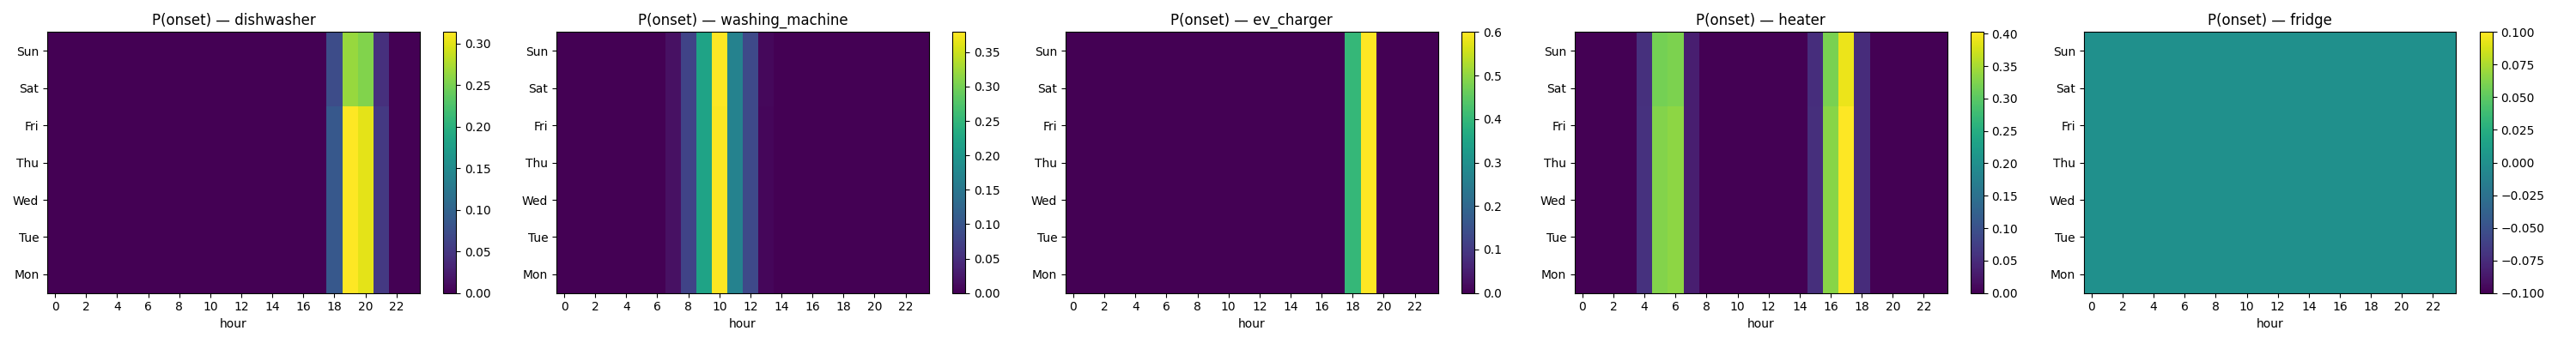

In [2]:
# Heatmap: predicted P(onset) as a function of (day-of-week, hour-of-day)
from datetime import datetime, timedelta, timezone
fig, axes = plt.subplots(1, len(appliances), figsize=(6*len(appliances), 4))
if len(appliances) == 1: axes = [axes]
base = datetime(2025, 1, 6, 0, tzinfo=timezone.utc)  # a Monday
for ax, app in zip(axes, appliances):
    grid = np.zeros((7, 24))
    for d in range(7):
        for h in range(24):
            t = base + timedelta(days=d, hours=h)
            probs = pred.predict_onsets(app, t, horizon_slots=4)
            grid[d, h] = probs.sum()
    im = ax.imshow(grid, aspect="auto", cmap="viridis", origin="lower")
    ax.set_xticks(range(0,24,2)); ax.set_yticks(range(7))
    ax.set_yticklabels(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
    ax.set_xlabel("hour"); ax.set_title(f"P(onset) — {app}")
    plt.colorbar(im, ax=ax)
plt.tight_layout(); plt.show()

KeyError: 'fridge'

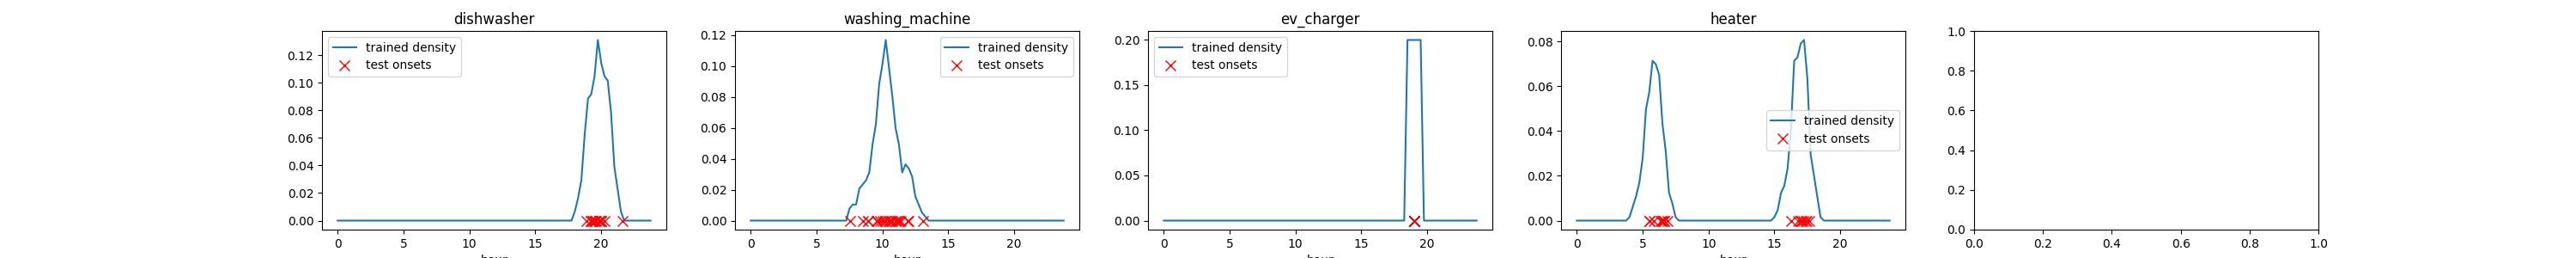

In [3]:
# Overlay test-split onsets on the predicted hour-of-day density
test = onsets[onsets["split"] == "test"]
fig, axes = plt.subplots(1, len(appliances), figsize=(6*len(appliances), 3))
if len(appliances) == 1: axes = [axes]
for ax, app in zip(axes, appliances):
    ax.plot(np.arange(96)/4, pred._density_24[app], label="trained density")
    th = test[test["appliance"] == app]["timestamp"].dt.hour + test[test["appliance"]==app]["timestamp"].dt.minute/60
    ax.plot(th, np.zeros(len(th)), "rx", markersize=8, label="test onsets")
    ax.set_title(app); ax.set_xlabel("hour"); ax.legend()
plt.tight_layout(); plt.show()